In [16]:
import pyranges
import pandas
import scanpy
import hdf5plugin
import anndata
import cellrank
import matplotlib
from matplotlib import pyplot
import cellrank
import numpy
import gseapy
import pygam
import seaborn
import pydeseq2
import pydeseq2.dds
import pydeseq2.ds
import scipy
import decoupler

In [17]:
# Load data from Cellrank and SDEvelo

working_directory = "RNA Sequencing Data/"
base_name = "cellrank_version_5"
adata = scanpy.read_h5ad(
    working_directory+f"/{base_name}_anndata.h5ad"
)
driver_df = pandas.read_csv(
    working_directory+f"{base_name}_driver_genes.csv",
    index_col=0
)
combined_driver_df = pandas.read_csv(
    working_directory+f"{base_name}_driver_genes_combined.csv",
    index_col=0
)

In [18]:
# Load adata with raw counts and filter

adata_raw = scanpy.read_h5ad(
    working_directory+f"/splice_counts_mm10.h5ad"
)

# Calculate proportion of mitochondrial genes
adata_raw.var["mt"] = adata_raw.var_names.str.startswith("mt-")
scanpy.pp.calculate_qc_metrics(
    adata_raw, qc_vars=["mt"], inplace=True, percent_top=[], log1p=False
)

scanpy.pp.calculate_qc_metrics(
    adata_raw, inplace=True, percent_top=[], log1p=False
)

# Filter cells by counts per cell, total counts and percent mitochondrial
included_cells = (adata_raw.obs["n_genes_by_counts"] >= 200)*(adata_raw.obs['total_counts'] <= 150000)*(adata_raw.obs['pct_counts_mt'] < 10)
adata_raw = adata_raw[included_cells]
print(adata_raw)

View of AnnData object with n_obs × n_vars = 12791 × 48526
    obs: 'barcode', 'batch', 'sample', 'group', 'day', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt'
    var: 'ensemble_ids', 'gene_symbol', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
    uns: 'sample_colors'
    obsm: 'X_fdl', 'X_umap'
    layers: 'ambiguous', 'matrix', 'spliced', 'unspliced'


In [19]:
# Read ChIP-seq targets

base_name = "ChIP Sequencing Data/chipseq_targets"

hic2_target_scores = pandas.read_csv(f"{base_name}_hic2_scores.csv", index_col=0)
klf4_hic2_target_scores = pandas.read_csv(f"{base_name}_klf4_hic2_scores.csv", index_col=0)
klf4_control_target_scores = pandas.read_csv(f"{base_name}_klf4_control_scores.csv", index_col=0)

hic2_targets = numpy.loadtxt(f"{base_name}_hic2_targets.txt", dtype=numpy.dtypes.StringDType())
klf4_hic2_targets = numpy.loadtxt(f"{base_name}_klf4_hic2_targets.txt", dtype=numpy.dtypes.StringDType())
klf4_control_targets = numpy.loadtxt(f"{base_name}_klf4_control_targets.txt", dtype=numpy.dtypes.StringDType())
klf4_targets = numpy.intersect1d(klf4_hic2_targets, klf4_control_targets)
shared_targets = numpy.intersect1d(hic2_targets, klf4_targets)

# Differential expression in bulk data with PyDEseq2

In [127]:
# Load bulk differential expression results

bulk_de = pandas.read_csv("RNA Sequencing Data/bulk_differential_expression.csv", index_col=0)
bulk_metadata = pandas.read_csv("RNA Sequencing Data/bulk_sequencing_metadata.csv", index_col=0)
samples = bulk_metadata.index.to_list()
reprogramming_columns = bulk_de.columns[bulk_de.columns.str.contains("Reprogramming")]
reprogramming_de = bulk_de[reprogramming_columns]

# Identify ChipSeq targets of Hic2

In [128]:
# Variable genes and Cellrank drivers
variable_genes = adata.var_names.to_numpy()
variable_in_bulk = numpy.intersect1d(variable_genes, bulk_de.index.to_numpy())
stem_cell_drivers = driver_df.sort_values("Day 12 Control_corr", ascending=True).head(200).index.to_numpy()
dead_end_drivers = driver_df.sort_values("Day 12 Control_corr", ascending=False).head(200).index.to_numpy()

In [129]:
# Load list of transcription factors

tf_df = pandas.read_csv("ChIP Sequencing Data/Mus_musculus_TF.txt", sep="\t")
tf_array = tf_df["Symbol"].to_numpy()

In [130]:
differentially_expressed_genes = reprogramming_de.loc[variable_in_bulk].query("`Reprogramming p adjusted` < 0.05").index.to_numpy()

In [133]:
# Find Hic2 target TFs that change significantly during reprogramming

# All target transcription factors
target_tfs = numpy.intersect1d(hic2_targets, tf_array)

# Target transcription factors for which Hic2 changes expression significantly
de_target_tfs = numpy.intersect1d(target_tfs, differentially_expressed_genes)

In [134]:
# Differentially expressed targets that are drivers of dead end

de_dead_end_drivers = numpy.intersect1d(de_target_tfs, dead_end_drivers)
reprogramming_de.loc[de_dead_end_drivers].sort_values("Reprogramming LFC")

,Reprogramming LFC,Reprogramming p value,Reprogramming p adjusted,Reprogramming base mean
Ovol1,-1.451013,5.370601e-15,8.644510e-14,680.945017
Barx2,-1.207086,7.786359e-23,2.699537e-21,270.806735
Tlx2,-1.107785,1.796624e-12,2.177406e-11,585.037236
Hoxa7,-1.072721,4.574495e-08,3.138826e-07,295.011074
Zbtb7c,-0.943320,3.528526e-59,8.875744e-57,1521.129230
Dmrtc2,-0.917730,6.004984e-06,3.002863e-05,104.620388
Hmgb3,-0.857015,1.214838e-16,2.360299e-15,1523.258054
Phox2a,-0.313819,7.560415e-05,3.123642e-04,183.685399


All dead end driver TFs that are targets of Hic2 are differentially expressed. Tlx2 is an interesting targets that have not been linked to reprogramming efficiency before. It is a clearer reprogramming driver in Hic2 OX than in control. Hoxa7 and Hmgb3 do not look like drivers in the Cellrank plot. Zbtb7 only looks like a driver in Hic2, and it has much higher expression in Hic2.

In [135]:
# Check which of them are also targets of Klf4

numpy.intersect1d(de_dead_end_drivers, klf4_targets)

array(['Barx2', 'Hoxa7', 'Ovol1', 'Phox2a', 'Tlx2', 'Zbtb7c'],
      dtype=object)

In [136]:
# Differentially expressed targets that are drivers of stem cells

de_stem_cell_drivers = numpy.intersect1d(de_target_tfs, stem_cell_drivers)
reprogramming_de.loc[de_stem_cell_drivers].sort_values("Reprogramming LFC", ascending=False)

,Reprogramming LFC,Reprogramming p value,Reprogramming p adjusted,Reprogramming base mean
Sall1,1.516870,2.411844e-23,8.706573e-22,914.264618
Tfcp2l1,1.502553,2.618455e-11,2.759063e-10,2321.616881
Zfp42,1.344900,2.703821e-19,6.666513e-18,2688.373406
Tcf7l1,1.263931,1.424378e-14,2.177080e-13,582.207950
Jarid2,0.820343,1.439299e-09,1.214135e-08,2140.717811
Tcf7l2,0.753992,1.393588e-10,1.340578e-09,1162.635586
Rest,0.492894,1.298291e-05,6.121253e-05,2085.826504


All stem cell driver TFs that are targets of Hic2 except Klf2, Mycn and Tsc22d1 have differential expression.

In [137]:
# All of them are also targets of Klf4
numpy.intersect1d(de_stem_cell_drivers, klf4_targets)

array(['Jarid2', 'Rest', 'Sall1', 'Tcf7l1', 'Tcf7l2', 'Tfcp2l1', 'Zfp42'],
      dtype=object)

In [138]:
# Differentially expressed targets that are drivers of dead end and that are not necessarily transcription factors

de_targets = numpy.intersect1d(hic2_targets, differentially_expressed_genes)
de_dead_end_non_tfs = numpy.intersect1d(de_targets, dead_end_drivers)
reprogramming_de.loc[de_dead_end_non_tfs].sort_values("Reprogramming LFC").head(20)

,Reprogramming LFC,Reprogramming p value,Reprogramming p adjusted,Reprogramming base mean
Slurp1,-3.661155,5.712186e-51,9.931224e-49,817.514135
Krt16,-3.035999,8.784150e-72,3.643881e-69,4807.327708
Lgals7,-2.852198,6.954909e-75,3.498911e-72,1045.989920
Rtn4r,-2.632157,5.999204e-66,1.970155e-63,945.036806
Ly6g6c,-2.579183,8.230171e-81,5.259524e-78,1619.300369
Kcnn4,-2.563120,1.152596e-38,1.112373e-36,586.350923
Pkp1,-2.548214,1.496395e-146,1.769113e-142,2909.631813
Mal2,-2.539277,2.107776e-124,6.229796e-121,1414.525483
Ptprv,-2.299276,6.802069e-51,1.173978e-48,5091.571991
Krt13,-2.277049,6.572413e-17,1.314761e-15,2683.208805


Other factors to consider:
- Better Cellrank analysis, such as correlation with states early in trajectory, or at least ignoring very late latent times to ignore what happens when cells become stem cells.
- Differential expression in important parts of the trajectory, such as the Day 4 Control macrostate.
- Enrichment of motifs among differentially expressed genes. 
- Public ChipSeq data
- Public perturbation followed by expression data

# Activity of transcription factor targets

CollecTRI appears to be a useful database. Dorothea lacks many TFs such as Ovol1, Tlx2 and Hoxa7.

In [ ]:
# Load CollecTRI database

collectri_df = decoupler.op.collectri(organism="mouse")

In [ ]:
# Check Ovol1 targets

collectri_df.query("source == \"Ovol1\"")

,source,target,weight,resources,references,sign_decision
9262,Ovol1,Id2,1.0,ExTRI,15716349,default activation
11395,Ovol1,Myc,-1.0,ExTRI;NTNU.Curated,16636146,PMID
11924,Ovol1,Gadd45a,1.0,ExTRI,16908841,default activation
11925,Ovol1,Gadd45b,1.0,ExTRI,16908841,default activation
11926,Ovol1,Lemd3,1.0,ExTRI,16908841,default activation
11927,Ovol1,Sgk1,1.0,ExTRI,16908841,default activation
12197,Ovol1,Ovol2,-1.0,ExTRI;NTNU.Curated,17049212,PMID
12910,Ovol1,Ovol1,-1.0,ExTRI;GOA,17311813,PMID
14851,Ovol1,Chuk,1.0,ExTRI,18268325,default activation
19305,Ovol1,Cdh2,1.0,ExTRI,20463035,default activation


In [87]:
ovol1_targets = collectri_df.query("source == \"Ovol1\"")["target"].to_numpy()
reprogramming_de_stats.results_df.loc[ovol1_targets]

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
Id2,1669.476516,0.709558,0.162943,4.354635,1.332890e-05,6.273125e-05
Myc,18952.909643,-0.137470,0.083679,-1.642833,1.004176e-01,1.902238e-01
Gadd45a,381.938162,0.402600,0.109673,3.670918,2.416812e-04,9.070717e-04
Gadd45b,716.061569,0.407813,0.208509,1.955855,5.048224e-02,1.075557e-01
Lemd3,1320.406975,0.078918,0.044580,1.770268,7.668243e-02,1.524301e-01
Sgk1,507.045197,-0.575744,0.169050,-3.405763,6.597939e-04,2.276496e-03
Ovol2,47.086576,-0.377526,0.246902,-1.529050,1.262522e-01,2.287359e-01
Ovol1,680.945017,-1.451013,0.185601,-7.817914,5.370601e-15,8.644510e-14
Chuk,2215.038586,0.308015,0.067620,4.555098,5.236122e-06,2.647169e-05
Cdh2,2414.041323,0.392772,0.135501,2.898654,3.747684e-03,1.099156e-02


Ovol1 is downregulated by Hic2, meaning targets with weight 1 should be downregulated and weight -1 upregulated. Looking at Ovol2 targets suggest the reverse, that Ovol1 activity is increased.

In [89]:
combined_driver_df.loc[numpy.intersect1d(ovol1_targets, combined_driver_df.index)]

,Full correlation,Early correlation,Late correlation,Control correlation,Hic2 correlation
gene_names,,,,,
Gadd45a,0.107267,0.171192,0.136397,0.039284,0.123762
Gadd45b,0.347735,0.363438,0.073052,0.198679,0.121220
Id2,0.118439,0.133245,0.007033,0.097610,-0.077647
Myc,-0.348143,-0.206220,-0.560578,-0.308806,-0.253677
Ovol1,-0.443452,-0.387979,-0.506482,-0.364260,-0.098093
Sgk1,0.230731,0.095545,0.499026,0.337671,0.181043


In [90]:
tlx2_targets = collectri_df.query("source == \"Tlx2\"")["target"].to_numpy()
reprogramming_de_stats.results_df.loc[tlx2_targets]

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
Ret,23.091996,-0.732177,0.280192,-2.613130,0.008972,0.024003
Slc8a3,10.349976,-0.587062,0.502865,-1.167435,0.243035,0.382619
Phox2b,24.553547,0.657880,0.440967,1.491903,0.135725,0.242223
Phox2a,183.685399,-0.313819,0.079289,-3.957924,0.000076,0.000312
Anxa5,7650.349077,-0.373951,0.105238,-3.553380,0.000380,0.001373


In [91]:
collectri_df.query("source == \"Zbtb7c\"")

,source,target,weight,resources,references,sign_decision
22846,Zbtb7c,Cdkn1a,-1.0,ExTRI;NTNU.Curated,22253232,PMID
23002,Zbtb7c,Fasn,1.0,ExTRI;NTNU.Curated,22331133,PMID


In [92]:
# Estimate activities of TF targets

data = reprogramming_de_stats.results_df[["stat"]].T.dropna(axis=1)
tf_acts, tf_padj = decoupler.mt.ulm(data=data, net=collectri_df)
activities_df = pandas.DataFrame(data={"Activity": tf_acts.transpose()["stat"], "Adjusted p-value": tf_padj.transpose()["stat"]}, index=tf_acts.columns)

In [93]:
dead_end_drivers_with_activities = numpy.intersect1d(de_dead_end_drivers, activities_df.index).tolist()
stem_cell_drivers_with_activities = numpy.intersect1d(de_stem_cell_drivers, activities_df.index).tolist()

In [94]:
# Activities of dead end drivers

activities_df.loc[dead_end_drivers_with_activities]

,Activity,Adjusted p-value
Barx2,-3.007877,0.023179
Hoxa7,1.033242,0.532136
Ovol1,2.635745,0.053613
Phox2a,-1.663064,0.274246
Tlx2,-1.347002,0.391778


In [95]:
# Activities of stem cell drivers

activities_df.loc[stem_cell_drivers_with_activities]

,Activity,Adjusted p-value
Jarid2,-0.206559,0.911306
Rest,1.306793,0.411599
Sall1,1.085461,0.502709
Tcf7l1,-0.343872,0.852213
Tcf7l2,-0.345297,0.852213
Zfp42,2.184417,0.121129


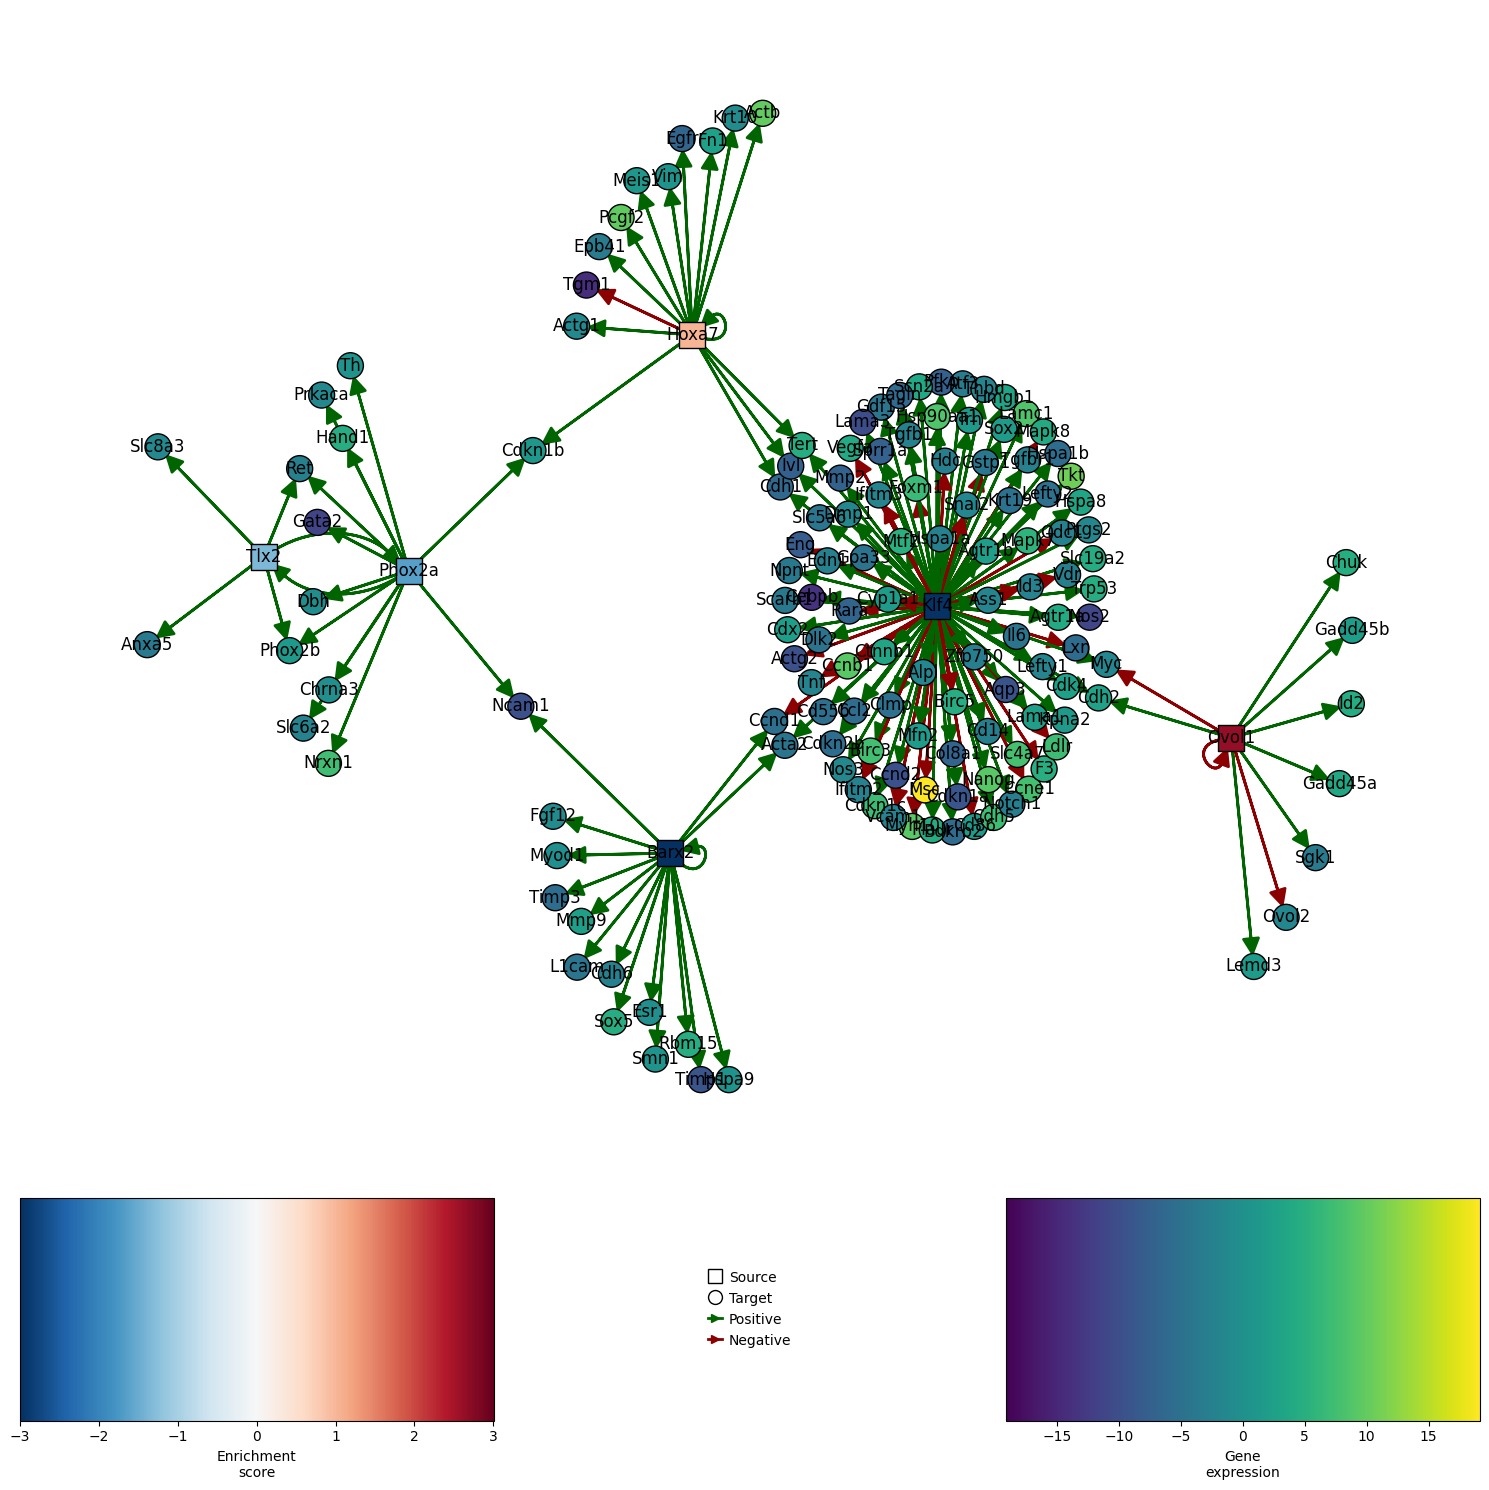

In [ ]:
# Plot dead end network

decoupler.pl.network(
    net=collectri_df,
    data=data,
    score=tf_acts,
    sources=dead_end_drivers_with_activities + ["Klf4"],
    targets=100,
    figsize=(15, 15),
    vcenter=True,
    by_abs=True,
    size_node=60,
)

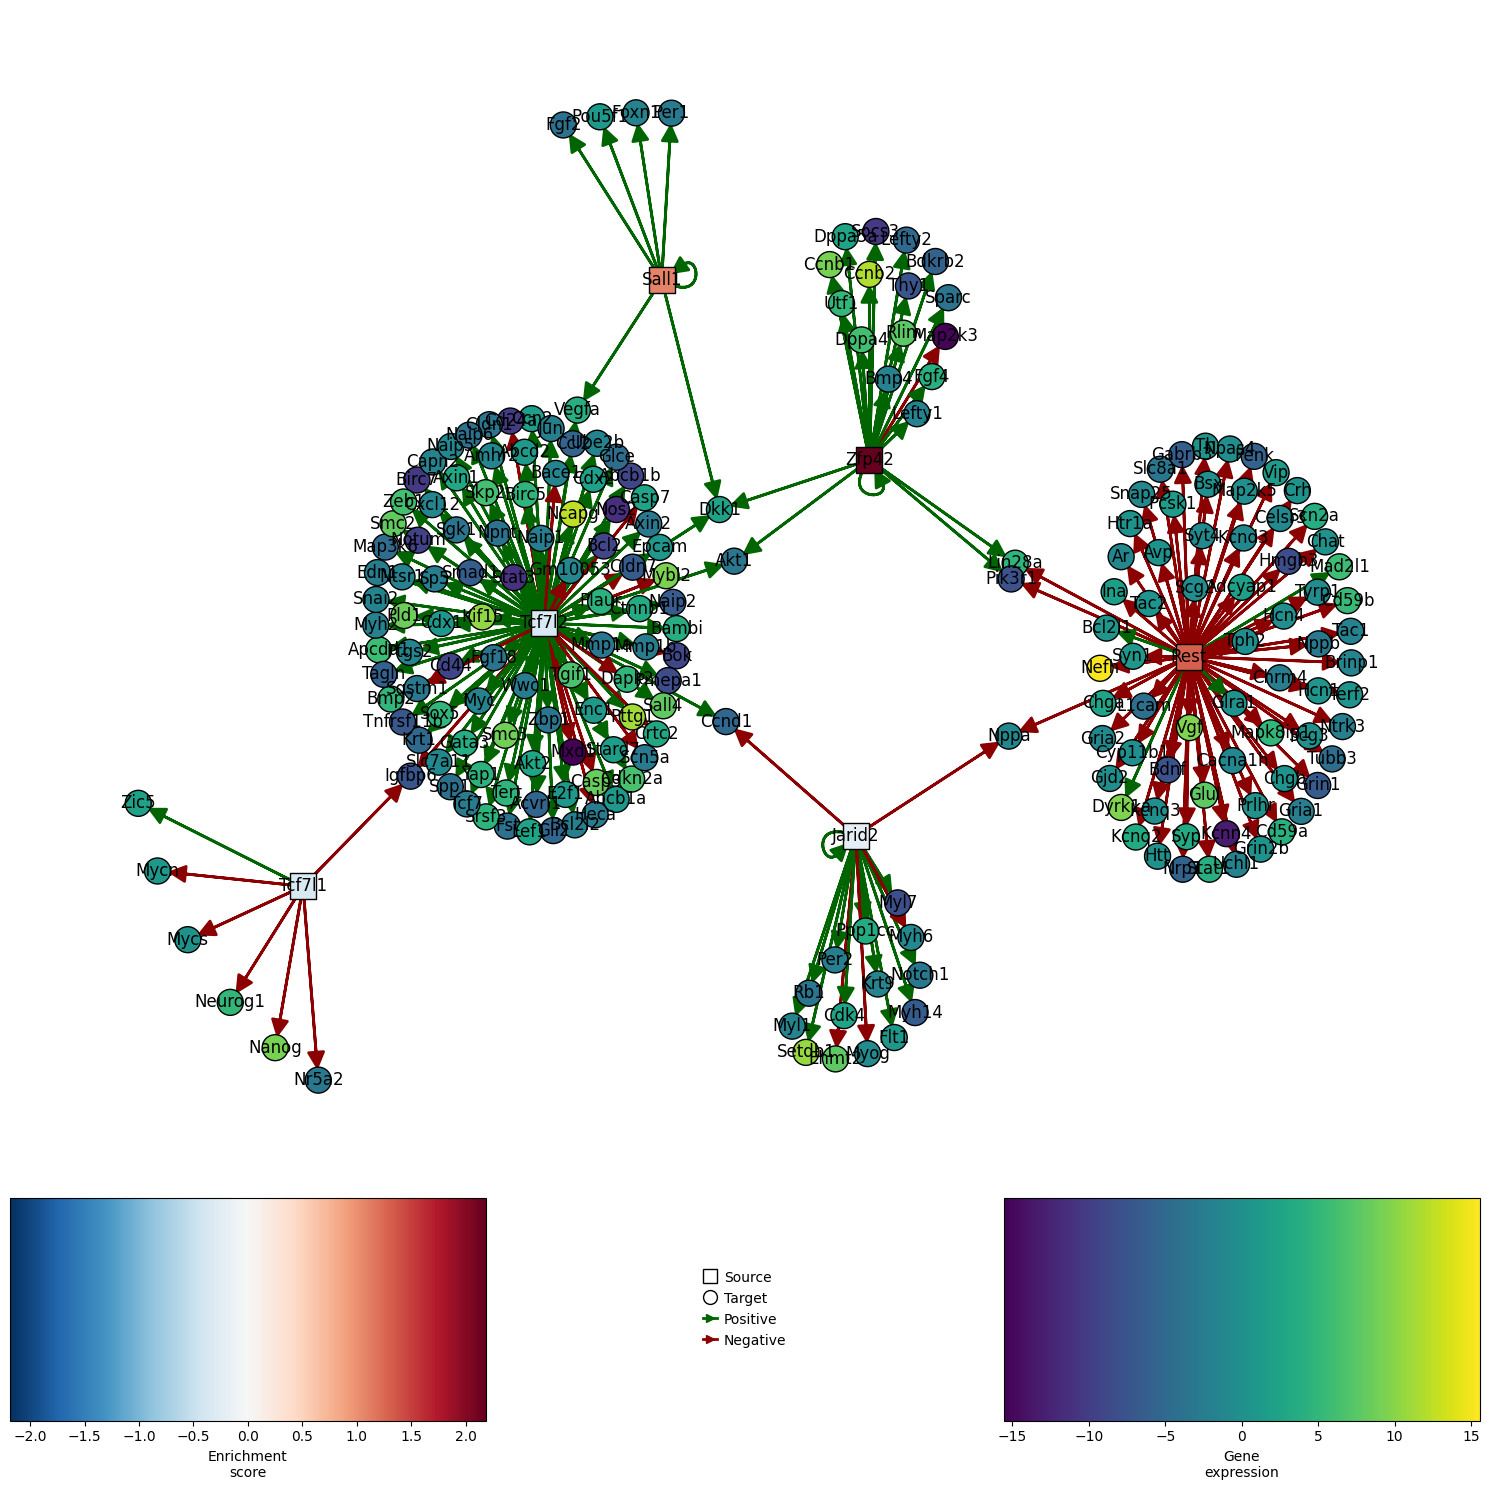

In [106]:
# Plot reprogramming network

decoupler.pl.network(
    net=collectri_df,
    data=data,
    score=tf_acts,
    sources=stem_cell_drivers_with_activities,
    targets=100,
    figsize=(15, 15),
    vcenter=True,
    by_abs=True,
    size_node=60,
)